# Customer Conversion Optimization & Prediction  
## 1. Exploratory Data Analysis (EDA)

This notebook explores the Bank Marketing dataset and examines the main drivers of customer conversion.

### Objectives
*  ⁠Load and inspect the dataset
*  ⁠Understand the target variable
*  ⁠Explore important customer and campaign variables
*  ⁠Identify early patterns that may influence conversion

In [6]:
# Import core libraries
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# Load dataset
df = pd.read_csv("../data/bank-full.csv", sep=";")

# Check shape
print("Dataset shape:", df.shape)

# Display first rows
df.head()

Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Inspect the Dataset
We inspect the column names, data types, and missing values.

In [11]:
# Display column names
print("Columns:")
print(df.columns.tolist())

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [12]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [13]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values by column:")
print(missing_values[missing_values > 0])

Missing values by column:
Series([], dtype: int64)


### Create the Target Variable
The original target column is 'y', with values ⁠'yes' and 'no⁠'.  
We convert it into a binary variable:
*  ⁠⁠ 1 ⁠ = customer subscribed
*  ⁠⁠ 0 ⁠ = customer did not subscribe

In [16]:
# Create binary target column
df["target"] = df["y"].map({"yes": 1, "no": 0})

# Check target distribution
df["target"].value_counts()

target
0    39922
1     5289
Name: count, dtype: int64

In [17]:
# Check target proportion
df["target"].value_counts(normalize=True)

target
0    0.883015
1    0.116985
Name: proportion, dtype: float64

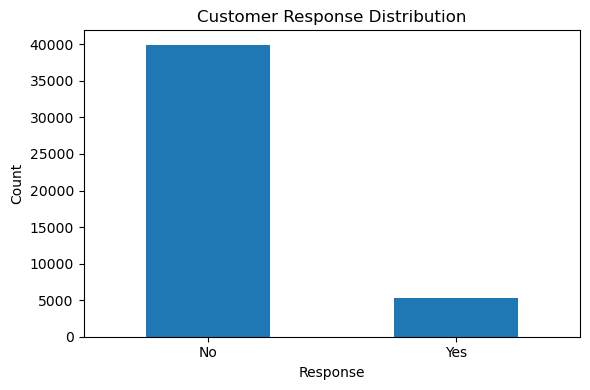

In [18]:
# Plot target distribution
plt.figure(figsize=(6, 4))
df["target"].value_counts().plot(kind="bar")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.title("Customer Response Distribution")
plt.xlabel("Response")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Summary Statistics
We review the numeric summary of the dataset to understand scale and spread.

In [19]:
# Numeric summary
df.describe()

,age,balance,day,duration,campaign,pdays,previous,target
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323,0.116985
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441,0.321406
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,1.000000


### Conversion Rate by Job
This helps identify whether occupation is associated with customer response.

In [20]:
# Compute conversion rate by job
job_conversion = df.groupby("job")["target"].mean().sort_values(ascending=False)

# Display results
job_conversion

job
student          0.286780
retired          0.227915
unemployed       0.155027
management       0.137556
admin.           0.122027
self-employed    0.118429
unknown          0.118056
technician       0.110570
services         0.088830
housemaid        0.087903
entrepreneur     0.082717
blue-collar      0.072750
Name: target, dtype: float64

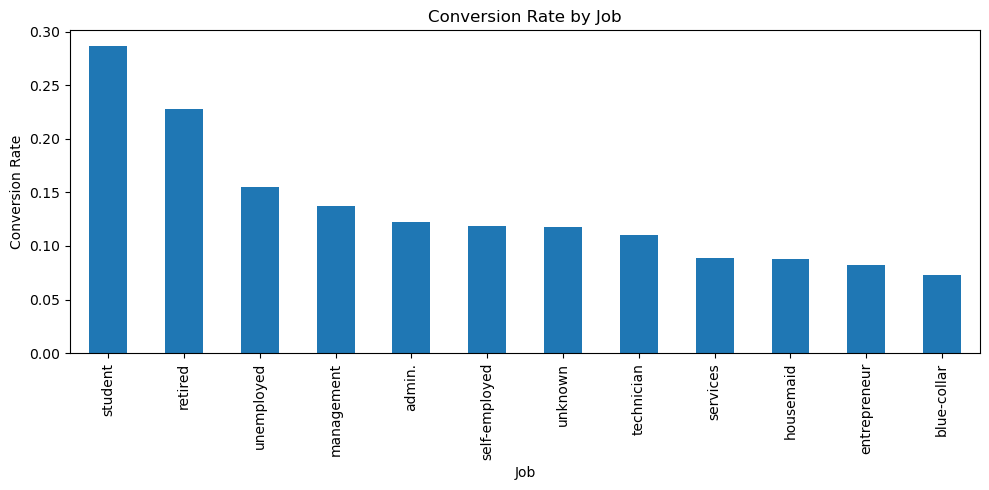

In [21]:
# Plot conversion rate by job
plt.figure(figsize=(10, 5))
job_conversion.plot(kind="bar")
plt.title("Conversion Rate by Job")
plt.xlabel("Job")
plt.ylabel("Conversion Rate")
plt.tight_layout()
plt.show()

### Conversion Rate by Education
Education may influence response patterns and campaign success.

In [26]:
# Compute conversion rate by education
education_conversion = df.groupby("education")["target"].mean().sort_values(ascending=False)

# Display results
education_conversion

education
tertiary     0.150064
unknown      0.135703
secondary    0.105594
primary      0.086265
Name: target, dtype: float64

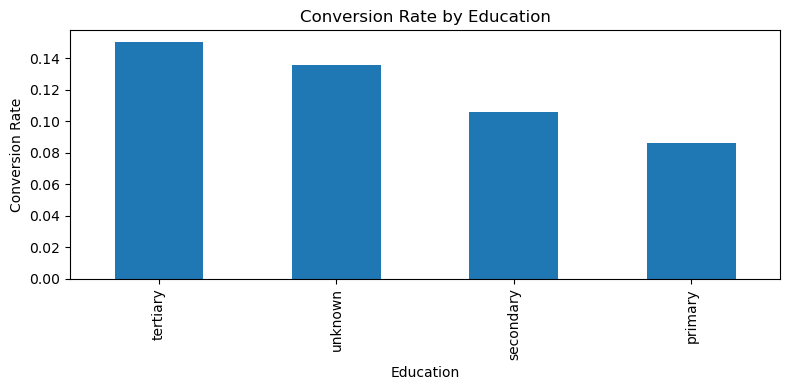

In [27]:
# Plot conversion rate by education
plt.figure(figsize=(8, 4))
education_conversion.plot(kind="bar")
plt.title("Conversion Rate by Education")
plt.xlabel("Education")
plt.ylabel("Conversion Rate")
plt.tight_layout()
plt.show()

### Call Duration and Conversion
The ⁠ duration ⁠ variable is often a strong predictor of conversion.  
However, it is only known after the call has happened, so it should be interpreted carefully.

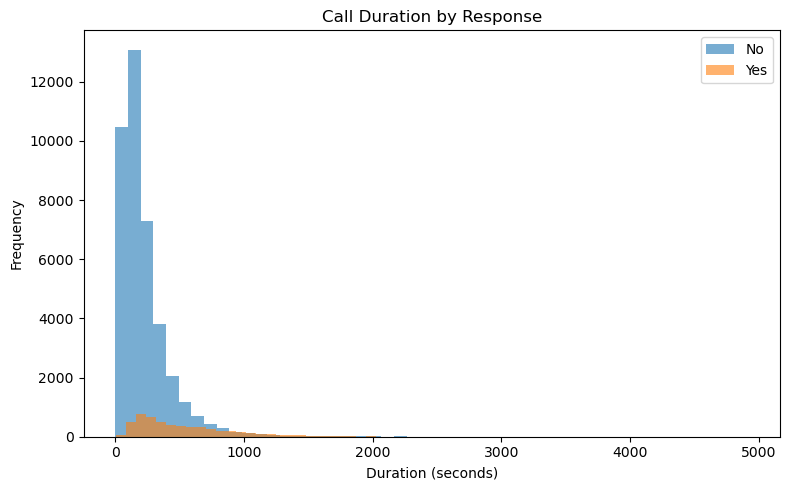

In [28]:
# Compare duration distributions by target
plt.figure(figsize=(8, 5))
plt.hist(df[df["target"] == 0]["duration"], bins=50, alpha=0.6, label="No")
plt.hist(df[df["target"] == 1]["duration"], bins=50, alpha=0.6, label="Yes")
plt.title("Call Duration by Response")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Balance and Conversion
We also inspect account balance across conversion outcomes.

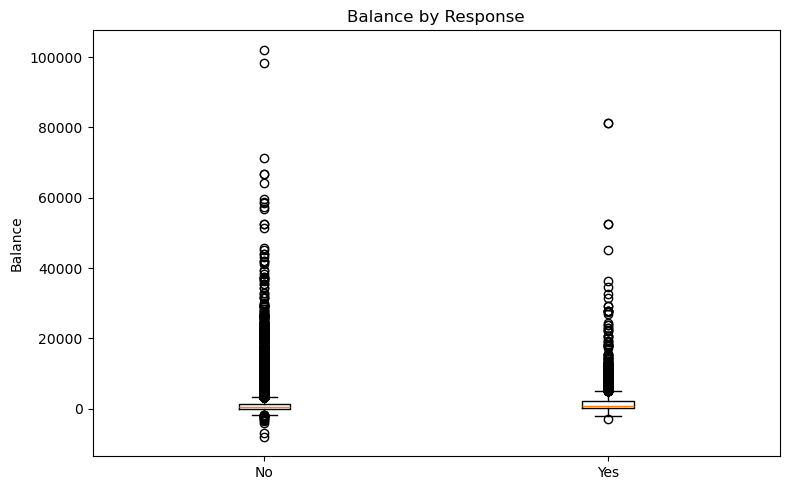

In [29]:
# Boxplot of balance by target
plt.figure(figsize=(8, 5))
plt.boxplot(
    [df[df["target"] == 0]["balance"], df[df["target"] == 1]["balance"]],
    tick_labels=["No", "Yes"]
)
plt.title("Balance by Response")
plt.ylabel("Balance")
plt.tight_layout()
plt.show()

### Preliminary Observations
Based on the EDA:
*  ⁠The dataset is imbalanced, with more non-conversions than conversions
*  ⁠Job and education show different conversion patterns
*  ⁠Call duration appears strongly associated with conversion
*  ⁠Additional feature engineering may improve predictive performance

The next notebook focuses on transforming the data into model-ready features.